# Make basic measurements

Make the measurements that are already possible to make with Prez's code. These are:  
* Minimum time taken for the mice to arrive the reward location in a trial. 
    It's only at animal spent > set amount of time, we would say the animal "arrived at the reward". That set amount of time was set to 2s in Prez's code
* Frequency of crossing the reward zone within a trial
* Fraction of time animal stayed at the reward location within a trial

## Helper functions

In [1]:
import sys
sys.path.append('..')
from util.data_loader import DataLoader
import util.utilities as util
import numpy as np
import pandas as pd
from tqdm import tqdm

def add_dist_to_trigger(position, triggerLoc):
    # Add distance to trigger in the position dataframe
    num_triggers = len(triggerLoc)
    for i in range(num_triggers):
        well_x = triggerLoc['x'][i]
        well_y = triggerLoc['y'][i]
        dist_col_name = f'distance_to_trigger_{i+1}'
        position[dist_col_name] = np.sqrt((position['x'].values - well_x)**2 + (position['y'].values - well_y)**2)

    return position

def compute_well_behav_metrics(x_loc, y_loc, well_coord):
    # Find the distance between each well center and the closest trajectory point over time
    distances = np.sqrt((x_loc - well_coord[0])**2 + (y_loc - well_coord[1])**2)
    # Get rid of heading and tail NaN values in distances
    distances = distances[~np.isnan(distances)]
    in_zone = distances < 8  # Assuming well radius is 8 cm

    # Find the time points when the animal is within the well zone
    time_in_well = np.where(in_zone)[0]
    time_to_arrive_zone = time_in_well[0] if len(time_in_well) > 0 else None

    # Get the fraction of time spent in the well zone
    fraction_time_in_well = len(time_in_well) / len(distances) if len(distances) > 0 else 0

    # Get the number of crossings into the well zone
    crossings = np.diff(in_zone.astype(int))
    num_crossings = np.sum(crossings == 1)

    return time_to_arrive_zone, fraction_time_in_well, num_crossings

def compute_well_behav_metrics_all(x_loc, y_loc, well_coords):
    all_metrics = {
        'time_to_arrive_zone': [],
        'fraction_time_in_well': [],
        'num_crossings': []
    }
    for well_coord in well_coords:
        metrics = compute_well_behav_metrics(x_loc, y_loc, well_coord)
        all_metrics['time_to_arrive_zone'].append(metrics[0])
        all_metrics['fraction_time_in_well'].append(metrics[1])
        all_metrics['num_crossings'].append(metrics[2])
    # Convert to pandas DataFrame for easier handling
    all_metrics = pd.DataFrame(all_metrics)
    return all_metrics

## Main

In [2]:
metadata = util.load_metadata()
dl = DataLoader(metadata.iloc[32])
position = dl.get_data('position')
cheeseboardMap = util.load_cheeseboard_map()
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')

In [4]:
metadata.iloc[32]

sub                      1
id                       A
date              20241209
ses                      5
trial_id                 5
trial_type               L
trial_type_day           2
test_type              NaN
usable                   1
trial_note             NaN
genotype              ChR2
test_order               e
remapping                0
short_duration           0
LFP                      0
animal_note            NaN
Name: 32, dtype: object

Text(0.5, 1.0, 'Animal Trajectory with Well Locations')

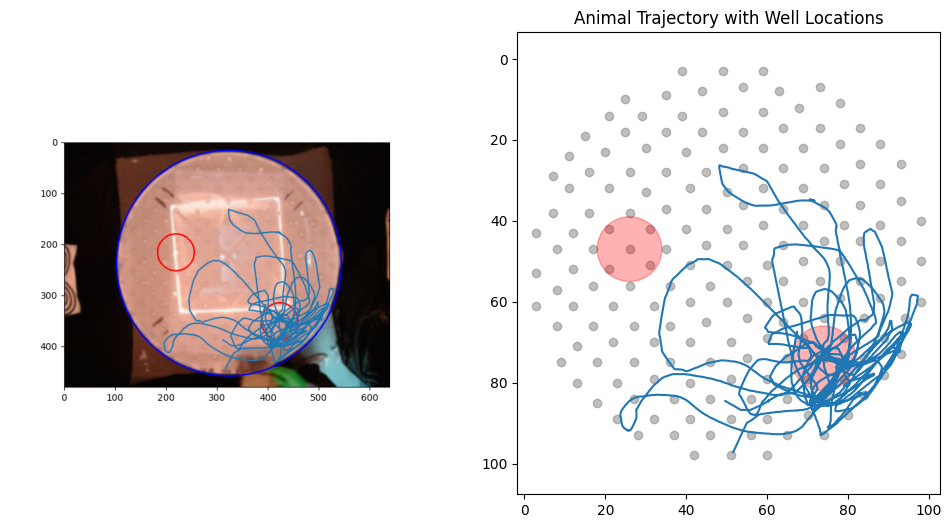

In [3]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1,2,figsize=(12,6), width_ratios=(1, 1))

axes[0].imshow(img)
axes[0].axis('off')

axes[1].plot(position['x'].values, position['y'].values)
axes[1].scatter(cheeseboardMap['x'].values, cheeseboardMap['y'].values, alpha=0.5, color='gray')
for i in range(len(triggerLoc)):
    x = triggerLoc['x'][i]
    y = triggerLoc['y'][i]
    circle = plt.Circle((x, y), 8, color='r', fill=True, linestyle='-', alpha=0.3)
    axes[1].add_artist(circle)
# Equalize axis scales
axes[1].axis('equal')
# axes[1].axis('off')
# Flip the y-axis to match the coordinate system
axes[1].invert_yaxis()
axes[1].set_title('Animal Trajectory with Well Locations')

In [ ]:
position_ = add_dist_to_trigger(position, triggerLoc)
# Next calculate the time to well

In [19]:
position_

,frame,t,x,y,distance_to_trigger_1,distance_to_trigger_2
0,136,0,51.62,97.20,56.359776,32.235142
1,137,7,51.90,96.60,55.955071,31.609650
2,138,22,52.16,96.00,55.545887,30.999768
3,139,37,52.44,95.44,55.186114,30.405710
4,140,53,52.70,94.90,54.838855,29.841247
...,...,...,...,...,...,...
5516,5652,183779,50.90,85.25,45.640689,25.693822
5517,5653,183849,50.60,85.06,45.318027,25.882110
5518,5654,183867,50.28,84.90,45.010314,26.104567
5519,5655,183912,49.97,84.70,44.674947,26.304579


In [5]:
k = compute_well_behav_metrics_all(x_loc, y_loc, well_coords)

In [ ]:

cheeseboardMap = util.load_cheeseboard_map()
metadata = util.load_metadata()

# Create a column for minimum time to well in the metadata
metadata['min_time_to_well'] = np.nan

for idx in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[idx])
    position = dl.get_data('position')
    if position is None:
        continue
    x_loc = position['smooth_trans_x'].values
    y_loc = position['smooth_trans_y'].values
    in_roi = position['inside_roi'].values
    x_loc[x_loc == -1] = np.nan
    y_loc[y_loc == -1] = np.nan



    # Get the trigger locations
    well_coords = []
    for i in range(len(triggerLoc)):
        cheeseboardMap_loc = cheeseboardMap[(cheeseboardMap['well_row'] == triggerLoc['well_row'].values[i]) & (cheeseboardMap['well_col'] == triggerLoc['well_col'].values[i])]
        well_coords.append((cheeseboardMap_loc['trans_X'].values[0], cheeseboardMap_loc['trans_Y'].values[0]))


    well_behav_metrics = compute_well_behav_metrics_all(x_loc, y_loc, well_coords)
    if np.nansum(well_behav_metrics['fraction_time_in_well']) == 0:
        continue
    min_time_to_well = np.nanmin(well_behav_metrics['time_to_arrive_zone'].values)
    metadata.at[idx, 'min_time_to_well'] = min_time_to_well

 20%|██        | 825/4110 [00:31<01:53, 28.89it/s]

The file 'E:\cheeseboard-data\derivatives\sub-010_id-AF\ses-17_date-20250624\behav\sub-010_ses-17_trial-01_data-position.csv' does not exist.


 32%|███▏      | 1301/4110 [00:49<01:32, 30.53it/s]

The file 'E:\cheeseboard-data\derivatives\sub-014_id-AJ\ses-04_date-20250711\behav\sub-014_ses-04_trial-04_data-position.csv' does not exist.


 76%|███████▌  | 3124/4110 [02:11<00:30, 31.97it/s]

The file 'E:\cheeseboard-data\derivatives\sub-031_id-I\ses-05_date-20241201\behav\sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4110/4110 [02:53<00:00, 23.74it/s]


In [ ]:
metadata_L = metadata[metadata['trial_type'] == 'L']#.reset_index(drop=True)

([<matplotlib.axis.XTick at 0x1ff6ad01b10>,
 [Text(0, 0, 'Day 1'),
  Text(1, 0, 'Day 2'),
  Text(2, 0, 'Day 3'),
  Text(3, 0, 'Day 4'),
  Text(4, 0, 'Day 5')])

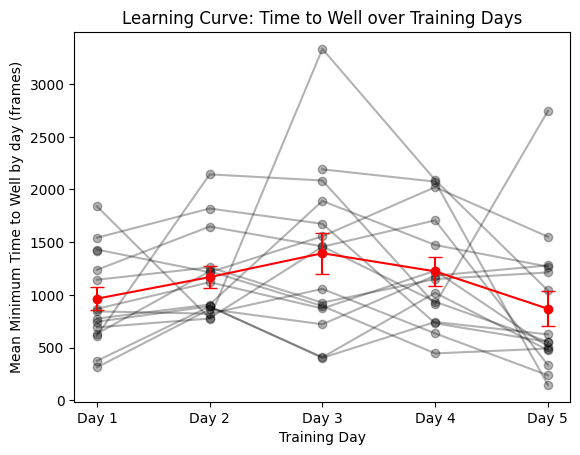

In [ ]:
performance_mat = []
for sub in range(1, 19):
    metadata_L_A = metadata_L[metadata_L['sub'] == sub]#.reset_index(drop=True)
    mean_performance_by_day = metadata_L_A.groupby('trial_type_day')['min_time_to_well'].mean().values
    if len(mean_performance_by_day)!=5:
        continue
    performance_mat.append(mean_performance_by_day)
    plt.plot(range(0,5), mean_performance_by_day, '-o',color='k', alpha=0.3)

performance_mat = np.vstack(performance_mat)
# Get the mean and standard error across subjects
mean_performance = np.nanmean(performance_mat, axis=0)
sem_performance = np.nanstd(performance_mat, axis=0) / np.sqrt(performance_mat.shape[0])
plt.errorbar(range(0,5), mean_performance, yerr=sem_performance, fmt='-o', color='r', capsize=5)
plt.xlabel('Training Day')
plt.ylabel('Mean Minimum Time to Well by day (frames)')
plt.title('Learning Curve: Time to Well over Training Days')

plt.xticks(range(0,5), labels=['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5'])

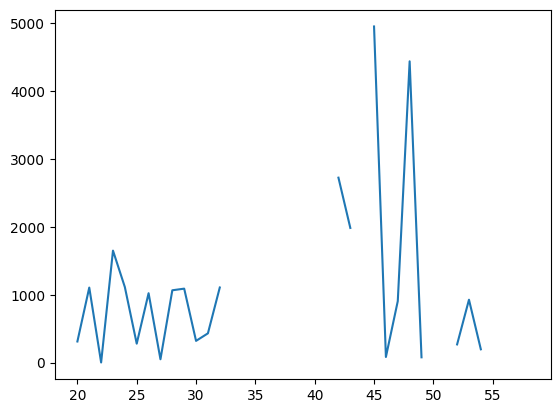

In [ ]:
metadata_L_A = metadata_L[metadata_L['sub'] == 1]

plt.plot(metadata_L_A['min_time_to_well'])